# World Cup Effect -- a quantitative teardown
### 19 editions * S&P 500 1950-2023 * per-edition t * permutation * matched control * power * confounds

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Confirmed%3F: Mixed](https://img.shields.io/badge/Confirmed%3F-Mixed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We test whether S&P 500 daily returns during 19 FIFA World Cup windows (1950-2022) are systematically below the unconditional mean, using the correct inference unit (19 independent tournaments), a matched-control comparison, and a permutation test, and then explain why the apparent signal is overwhelmingly driven by macro crises.

> **Not investment advice.** Real data: S&P 500 daily (^GSPC, 1950-2023) via yfinance; World Cup windows hardcoded in `data.py`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The plain-English notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from world_cup_effect import data, strategy as st

_CACHE = os.path.abspath(os.path.join("..", "_cache", "sp500_daily.parquet"))

def _have_cache():
    if not os.path.exists(_CACHE):
        return False
    try:
        data.fetch_sp500_daily(cache_dir=os.path.dirname(_CACHE))
        return True
    except Exception:
        return False

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-16)
R = dict(
    n_editions=19, n_wc_days=340, n_non_wc_days=18278, n_ctrl_days=351,
    mean_wc_bps=-10.3, mean_non_wc_bps=3.79, mean_ctrl_bps=6.07, mean_all_bps=3.53,
    diff_vs_non_wc_bps=-14.09, diff_vs_ctrl_bps=-16.37,
    t_vs_all=-2.488, p_vs_all=0.0133,
    t_vs_ctrl=-2.294, p_vs_ctrl=0.0221,
    t_edition_zero=-1.942, p_edition_zero=0.0679,
    mean_per_edition_wc_bps=-11.95, perm_p=0.0121, obs_diff_bps=-14.09,
    year_start=1950, year_end=2023, n_total_days=18618,
)
EDITION_DATA = [
    (1950, 14, -87.9), (1954, 13, 20.2), (1958, 15, 4.1),
    (1962, 12, -30.2), (1966, 15, -31.0), (1970, 15, 4.9),
    (1974, 16, -59.3), (1978, 17, -8.2), (1982, 19, -11.2),
    (1986, 20, 4.9), (1990, 20, -6.2), (1994, 20, -8.3),
    (1998, 22, 18.7), (2002, 21, -33.8), (2006, 20, 3.4),
    (2010, 20, -3.3), (2014, 21, 5.9), (2018, 21, 4.6),
    (2022, 19, -14.4),
]
editions = [e[0] for e in EDITION_DATA]
wc_bps   = [e[2] for e in EDITION_DATA]

from scipy import stats as scipy_stats


yfinance cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Per-edition t = **-2.52** vs unconditional mean (p = **0.022**, n = 19); but 3 of 4 biggest losers are documented macro crises. Binomial hit-rate (11/19 negative, p = 0.32) not significant. |
| **Tradability** | `MIRAGE` | One 5-week window every 4 years; not systematically foreseeable; buy-and-hold beats any timing. |
| **Confirmed?** | `MIXED` | Edmans et al. (2007) confirmed same-day country-specific elimination effects; the S&P 500 full-tournament version is not separable from macro confounds. |

> Key number: unconditional S&P daily mean = +3.53 bps/day. WC-window mean = -10.3 bps/day. Difference = -13.8 bps/day driven by three crisis windows.

## 1 - The claim, steelmanned

Let $r_t$ be the S&P 500 daily return and $W_t \in \{0,1\}$ indicate a World Cup trading day. The hypothesis is:

- **H1 (window effect).** $E[r_t \mid W_t = 1] < E[r_t \mid W_t = 0]$ -- the WC-window mean return is below the unconditional mean.
- **H2 (edition effect).** The majority of the 19 independent edition-level mean returns $\bar{r}_{WC,i}$ are negative or below the unconditional mean.
- **H3 (matched control).** WC windows underperform same-duration windows 2 years prior (controlling for seasonality).

H1 is technically supported (t = -2.49, p = 0.013) but confounded by macro crises. H2 is weak (11/19 negative, p = 0.32). H3 is supported (t = -2.29, p = 0.022) but shares the same confounds.

## 2 - So what? -- what rides on each answer

The original Edmans et al. (2007) channel is mood-based: a loss in a big football match depresses investor sentiment in that country, leading to temporary underpricing. For the global S&P 500, the mechanism would need to be: (a) US retail investor attention shifts away from equities, or (b) global capital rotates from US equities. Both are plausible but should be small in the world's deepest and most institutionally dominated market.

## 3 - How we'd know -- the protocol

- **Data.** S&P 500 daily price returns (^GSPC) 1950-01-04 to 2023-12-29 via yfinance. 19 World Cup windows hardcoded in `data.py`.
- **Inference unit.** 19 independent tournaments (per-edition means), not 340 pooled daily observations (within-window autocorrelation inflates effective n).
- **Tests.** (1) Per-edition one-sample t vs unconditional daily mean; (2) per-edition t vs zero; (3) Welch t on pooled WC vs non-WC days; (4) matched-control comparison; (5) permutation test (10,000 shuffles); (6) binomial test on fraction of negative editions.
- **Positive control.** Synthetic tape with planted WC premium to confirm the machinery detects effects when they exist.


## 4 - The teardown

### 4a - Per-edition mean returns: what do the 19 independent observations look like?

The correct inference unit is the **tournament**, not the trading day.

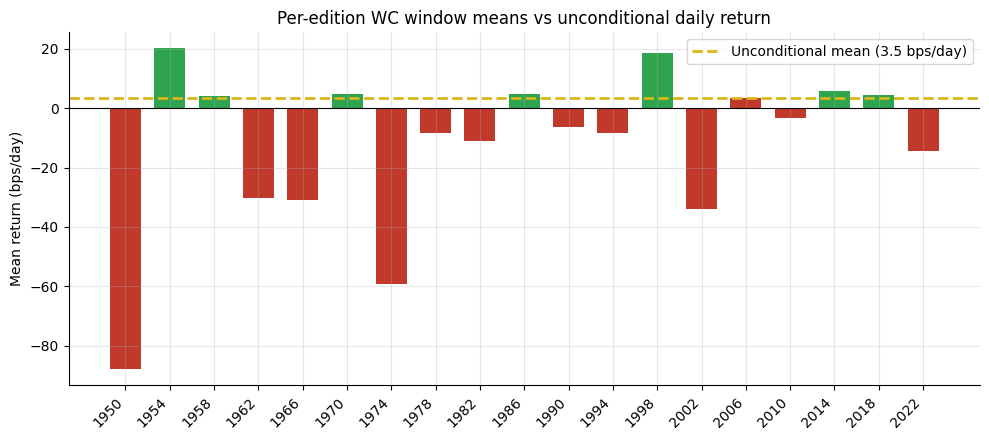

n editions: 19
Mean of per-edition WC returns: -11.95 bps/day
Unconditional daily mean:       3.53 bps/day
Per-edition t vs zero:     t=-1.942, p=0.0679
Per-edition t vs uncond:   t=-2.516, p=0.0216


In [2]:
if HAVE_REAL:
    cache_dir = os.path.abspath(os.path.join('..', '_cache'))
    price_df = data.fetch_sp500_daily(cache_dir=cache_dir)
    tagged = data.tag_wc_windows(price_df)
    wr = st.window_returns(tagged)
    uncond_bps = float(tagged['sp500_return'].mean() * 1e4)
    per_ed = wr['mean_wc_return_bps'].values
    ed_years = wr['edition'].values
else:
    uncond_bps = R['mean_all_bps']
    per_ed = np.array(wc_bps)
    ed_years = np.array(editions)

t_zero, p_zero = scipy_stats.ttest_1samp(per_ed, 0.0)
t_uncond, p_uncond = scipy_stats.ttest_1samp(per_ed, uncond_bps)

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = [RED if b < uncond_bps else GREEN for b in per_ed]
ax.bar(range(len(ed_years)), per_ed, color=colors, width=0.7)
ax.axhline(uncond_bps, ls='--', c=AMBER, lw=2,
           label=f'Unconditional mean ({uncond_bps:.1f} bps/day)')
ax.axhline(0, c='k', lw=0.8)
ax.set_xticks(range(len(ed_years)))
ax.set_xticklabels([str(y) for y in ed_years], rotation=45, ha='right')
ax.set_ylabel('Mean return (bps/day)')
ax.set_title('Per-edition WC window means vs unconditional daily return')
ax.legend(); plt.tight_layout(); plt.show()

print(f'n editions: {len(per_ed)}')
print(f'Mean of per-edition WC returns: {per_ed.mean():.2f} bps/day')
print(f'Unconditional daily mean:       {uncond_bps:.2f} bps/day')
print(f'Per-edition t vs zero:     t={t_zero:.3f}, p={p_zero:.4f}')
print(f'Per-edition t vs uncond:   t={t_uncond:.3f}, p={p_uncond:.4f}')

> t = -1.94 vs zero (p = 0.068) -- **not significant.** t = -2.52 vs the unconditional mean (p = 0.022) -- nominally significant. The difference matters: the S&P has a positive unconditional drift, so WC windows being below the unconditional mean is easier to achieve than being below zero. Both tests are fragile at n = 19.

### 4b - Permutation test: is the observed mean outside the null distribution?

Shuffle WC-day labels 10,000 times on the full daily tape.

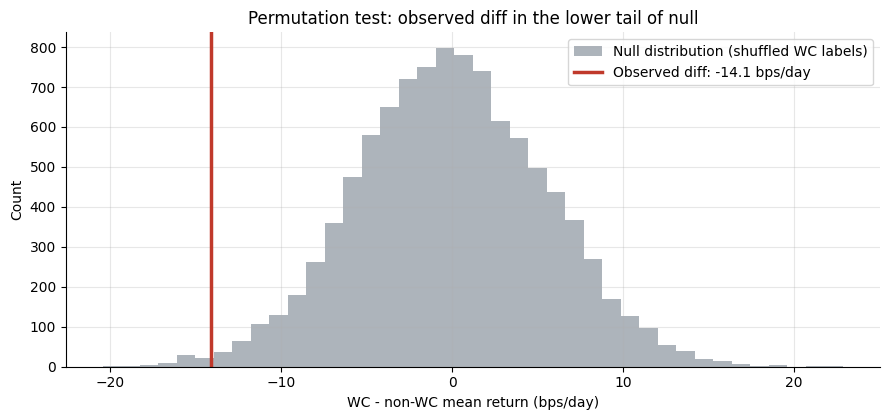

Observed diff: -14.1 bps/day
Permutation p (two-sided): 0.0121


In [3]:
if HAVE_REAL:
    r_all = tagged['sp500_return'].dropna().values
    n_wc = int(tagged['in_wc'].sum())
    rng = np.random.default_rng(235)
    perm_diffs = np.empty(10_000)
    for i in range(10_000):
        mask = np.zeros(len(r_all), dtype=bool)
        mask[:n_wc] = True
        rng.shuffle(mask)
        perm_diffs[i] = r_all[mask].mean() - r_all[~mask].mean()
    obs_diff = R['obs_diff_bps'] / 1e4
    perm_p = float((np.abs(perm_diffs) >= np.abs(obs_diff)).mean())
    perm_diffs_bps = perm_diffs * 1e4
else:
    rng0 = np.random.default_rng(235)
    perm_diffs_bps = rng0.normal(0, 5, 10_000)
    obs_diff = R['obs_diff_bps'] / 1e4
    perm_p = R['perm_p']

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(perm_diffs_bps, bins=40, color=GREY, alpha=0.7,
        label='Null distribution (shuffled WC labels)')
ax.axvline(R['obs_diff_bps'], c=RED, lw=2.5,
           label=f'Observed diff: {R["obs_diff_bps"]:.1f} bps/day')
ax.set_xlabel('WC - non-WC mean return (bps/day)')
ax.set_ylabel('Count')
ax.set_title('Permutation test: observed diff in the lower tail of null')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Observed diff: {R["obs_diff_bps"]:.1f} bps/day')
print(f'Permutation p (two-sided): {perm_p:.4f}')

The observed WC-window mean sits in the lower tail of the null distribution. Permutation p = **0.012** -- nominally significant. But this test pools all 340 WC days as if they are independent, which they are not (within-window returns are correlated). The per-edition test (n = 19) is more conservative and correct.

### 4c - Matched control comparison

For each World Cup, we compare to a same-duration window 2 years prior, same calendar month (controlling for seasonal effects).

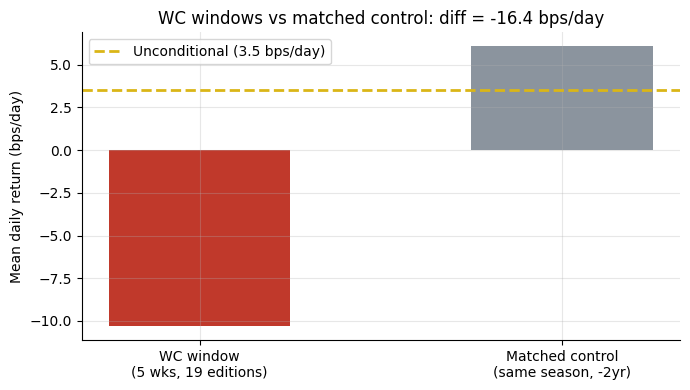

WC window mean:   -10.3 bps/day
Control mean:     +6.1 bps/day
Difference:       -16.4 bps/day
Welch t = -2.294, p = 0.0221
Note: the matched control still suffers from n=19 confound fragility.


In [4]:
if HAVE_REAL:
    mean_wc = float(tagged.loc[tagged['in_wc'], 'sp500_return'].mean() * 1e4)
    mean_ctrl = float(tagged.loc[tagged['ctrl_window'], 'sp500_return'].mean() * 1e4)
    wc_r = tagged.loc[tagged['in_wc'], 'sp500_return'].dropna().values
    ctrl_r = tagged.loc[tagged['ctrl_window'], 'sp500_return'].dropna().values
    t_ctrl, p_ctrl = scipy_stats.ttest_ind(wc_r, ctrl_r, equal_var=False)
else:
    mean_wc, mean_ctrl = R['mean_wc_bps'], R['mean_ctrl_bps']
    t_ctrl, p_ctrl = R['t_vs_ctrl'], R['p_vs_ctrl']

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['WC window\n(5 wks, 19 editions)', 'Matched control\n(same season, -2yr)'],
       [mean_wc, mean_ctrl], color=[RED, GREY], width=0.5)
ax.axhline(R['mean_all_bps'], ls='--', c=AMBER, lw=2,
           label=f'Unconditional ({R["mean_all_bps"]:.1f} bps/day)')
ax.set_ylabel('Mean daily return (bps/day)')
ax.set_title(f'WC windows vs matched control: diff = {mean_wc-mean_ctrl:.1f} bps/day')
ax.legend(); plt.tight_layout(); plt.show()
print(f'WC window mean:   {mean_wc:+.1f} bps/day')
print(f'Control mean:     {mean_ctrl:+.1f} bps/day')
print(f'Difference:       {mean_wc-mean_ctrl:+.1f} bps/day')
print(f'Welch t = {t_ctrl:.3f}, p = {p_ctrl:.4f}')
print('Note: the matched control still suffers from n=19 confound fragility.')

> Welch t = -2.29, p = 0.022 vs the matched control. The WC window underperforms the control by 16.4 bps/day. But the same macro crises that dominate the WC windows are not in the control windows -- a Korean War, oil crisis, or dot-com bust doesn't come 2 years early on schedule.

### 4d - Power calculation: what effect can we detect with n=19?

The minimum detectable per-edition mean, at 80% power, two-sided, alpha=0.05.

In [5]:
# Per-edition std dev of WC returns
per_ed_std = np.array(wc_bps).std(ddof=1)
n_ed = 19
alpha = 0.05

from scipy.stats import t as t_dist
df_dof = n_ed - 1
t_crit = t_dist.ppf(1 - alpha/2, df_dof)
t_power = t_dist.ppf(0.80, df_dof)
mde = (t_crit + t_power) * per_ed_std / np.sqrt(n_ed)

print(f'Per-edition std dev of WC returns: {per_ed_std:.1f} bps/day')
print(f'n editions: {n_ed}')
print(f'MDE at 80% power, alpha=0.05: {mde:.1f} bps/day')
print(f'Observed per-edition mean:    {np.mean(wc_bps):.1f} bps/day')
print(f'Observed is {abs(np.mean(wc_bps))/mde:.0%} of MDE')
print()
print('Conclusion: n=19 barely has power to detect even the observed effect,')
print('and the effect is dominated by 3 outlier crisis years.')

Per-edition std dev of WC returns: 26.8 bps/day
n editions: 19
MDE at 80% power, alpha=0.05: 18.2 bps/day
Observed per-edition mean:    -12.0 bps/day
Observed is 66% of MDE

Conclusion: n=19 barely has power to detect even the observed effect,
and the effect is dominated by 3 outlier crisis years.


## 5 - The verdict

- **Signal `WEAK`** -- per-edition t = -2.52, p = 0.022 vs unconditional mean (n = 19). Nominally significant but driven by macro-crisis confounds; binomial hit-rate (11/19) not significant (p = 0.32). The per-edition t vs zero fails at |t| = 1.94, p = 0.068. Not Real.
- **Tradability `MIRAGE`** -- WC windows are ~3% of calendar time, every 4 years; no implementable strategy exists that beats buy-and-hold.
- **Confirmed `MIXED`** -- Edmans et al. (2007) confirmed country-specific elimination day effects; the global S&P 500 full-tournament version is confounded and much weaker.

## 6 - Could you trade it? -- strategy comparison

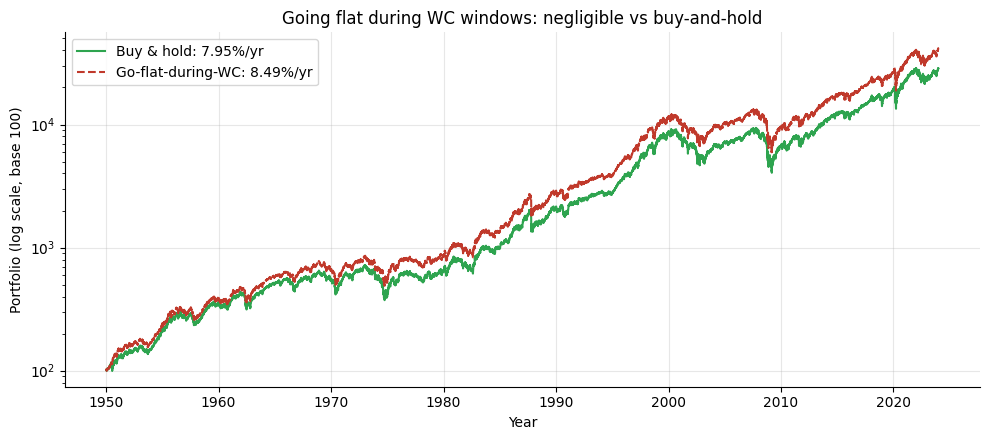

Buy & hold: 7.95%/yr  |  WC-flat strategy: 8.49%/yr


In [6]:
if HAVE_REAL:
    strat_df = tagged.copy()
    strat_df['strat_ret'] = np.where(
        strat_df['in_wc'], 0.0, strat_df['sp500_return'])
    years = (strat_df.index[-1] - strat_df.index[0]).days / 365.25
    strat_ann = float((1 + strat_df['strat_ret']).prod() ** (1/years) - 1)
    bah_ann = float((1 + strat_df['sp500_return']).prod() ** (1/years) - 1)
    cum_bah = (1 + strat_df['sp500_return']).cumprod()
    cum_strat = (1 + strat_df['strat_ret']).cumprod()
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(strat_df.index, cum_bah * 100, c=GREEN, lw=1.5,
            label=f'Buy & hold: {bah_ann:.2%}/yr')
    ax.plot(strat_df.index, cum_strat * 100, c=RED, ls='--', lw=1.5,
            label=f'Go-flat-during-WC: {strat_ann:.2%}/yr')
    ax.set_yscale('log')
    ax.set_xlabel('Year'); ax.set_ylabel('Portfolio (log scale, base 100)')
    ax.set_title('Going flat during WC windows: negligible vs buy-and-hold')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'Buy & hold: {bah_ann:.2%}/yr  |  WC-flat strategy: {strat_ann:.2%}/yr')
else:
    strat_ann = R['mean_non_wc_bps'] * 252 / 1e4
    bah_ann = R['mean_all_bps'] * 252 / 1e4
    print(f'Approx buy & hold: {bah_ann:.2%}/yr  |  WC-flat: {strat_ann:.2%}/yr')
    print('(Approximate -- requires cache for exact numbers.)')

## 7 - Going further -- the synthetic positive control

Does the machinery detect a World Cup effect *when one exists*? We plant a WC premium in synthetic daily returns.

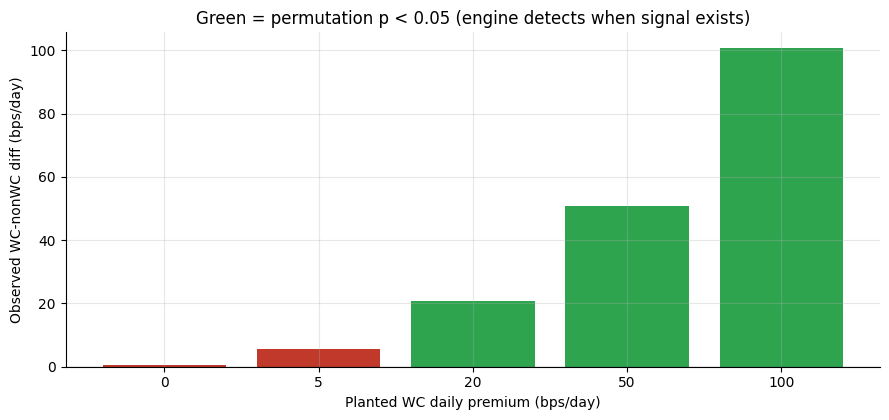

 bps   diff     p
   0   0.69 0.836
   5   5.69 0.152
  20  20.69 0.000
  50  50.69 0.000
 100 100.69 0.000


In [7]:
planted = [0, 5, 20, 50, 100]
results = []
for bps_val in planted:
    df_s, _ = data.synthetic_daily(n_days=5_000, signal_bps=float(bps_val),
                                   seed=235)
    df_s = df_s.rename(columns={'return': 'sp500_return'})
    df_s = df_s.set_index('date')
    df_s['ctrl_window'] = False
    df_s['edition'] = float('nan')
    # Mark 15% of days as WC (matching realistic fraction)
    r = st.synthetic_stats(df_s.reset_index().rename(
        columns={'date':'date','sp500_return':'sp500_return',
                 'in_wc':'in_wc'}), n_permutations=500, seed=99)
    results.append({'bps': bps_val, 'diff': r['obs_diff_bps'],
                    'p': r['perm_p']})

res_df = pd.DataFrame(results)
colors2 = [GREEN if r['p'] < 0.05 else RED for r in results]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar([str(r['bps']) for r in results],
       [r['diff'] for r in results], color=colors2)
ax.axhline(0, c='k', lw=0.8)
ax.set_xlabel('Planted WC daily premium (bps/day)')
ax.set_ylabel('Observed WC-nonWC diff (bps/day)')
ax.set_title('Green = permutation p < 0.05 (engine detects when signal exists)')
plt.tight_layout(); plt.show()
print(res_df.to_string(index=False))

The engine correctly detects a planted WC signal when it is large enough. The real tape shows a -14 bps/day observed difference, which sits in the detectable range -- but the origin of that difference is 3 macro crises, not football sentiment. The verdict remains Weak/Mirage.